## Exercise: Gaussian Mixture Models

#### In this exercise, we'll apply Gaussian Mixture Models to the iris dataset to understand clustering dynamics, evaluate the effectivenes of different numbers of clusters, and explore the impact of covariance types on clustering

### **Learning Objectives**
#### By the end of this exercise, you should be able to:
#### - Confidently implement Gaussian Mixture Models using Scikit-learn on any dataset
#### - Evaluate model performance with different number of clusters
#### - Understand the effect of different covariance types on the clustering outcome

### Exercises

### **Exercise 1: Load data**
#### For this exercise, we'll use the iris dataset. a famous multivariate dataset introduced by Sir Ronald Fisher in 1936, as an example of discriminant analysis. The dataset consists of 150 samples from **three species of Iris flowers** (Iris setosa, Iris virginica, and Iris versicolor) with **four features**: the length and width of the sepals and petals.

#### 1. Load the Iris dataset.
#### **HINT**: Use the `load_iris()` function.
#### 2. Apply PCA to reduce the feature space from four dimensions to two.
#### 3. Plot the PCA-reduced data, colouring each point by its species label to visually assess the natural clusters within the data.

In [1]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import numpy as np

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
n_components = 2

pca = PCA(
    n_components=n_components,
    random_state=42
)

X_reduced = pca.fit_transform(X)

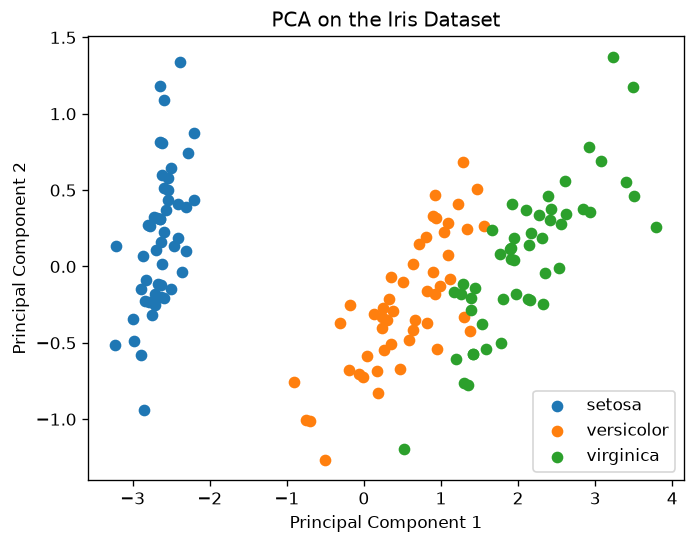

In [4]:
plt.figure(dpi=120)
for i, species in enumerate(iris.target_names):
    plt.scatter(
        X_reduced[y == i, 0],
        X_reduced[y == i, 1],
        label=species
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA on the Iris Dataset')
plt.legend()
plt.show()

### Exercise 2: Basic GMM application

#### Apply a Gaussian Mixture Model to the Iris dataset.
#### 1. Fit a GMM to the PCA-reduced data
#### 2. Use three components (as suggested by the original labels)
#### 3. Plot the clustering results, showing the data points coloured by cluster

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


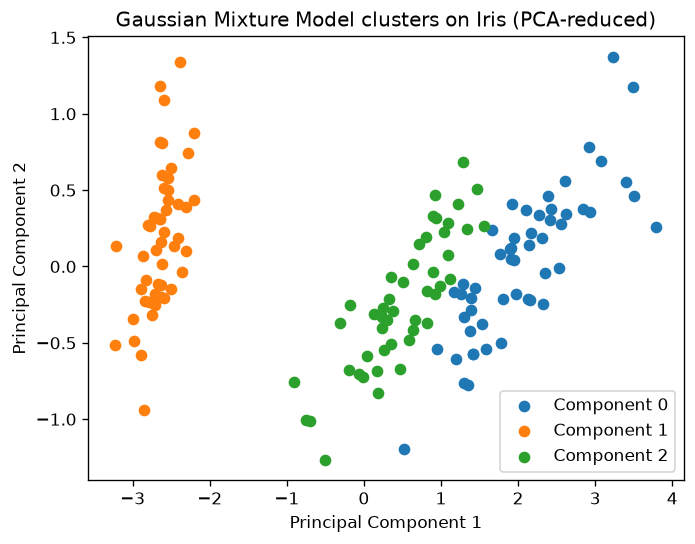

In [5]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

labels = gmm.fit_predict(X_reduced)

plt.figure(dpi=120)
for i in range(3):
    subset = X_reduced[labels == i]
    plt.scatter(
        subset[:, 0],
        subset[:, 1],
        label=f'Component {i}'
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Gaussian Mixture Model clusters on Iris (PCA-reduced)')
plt.legend()
plt.show()

### Exercise 3: Finding the optimal number of clusters

#### Determine the optimal number of clusters for the Iris dataset using the Bayesian Information Criterion (BIC).
#### 1. Fit GMMs with different numbers of components (from 1 to 6)
#### 2. Calculate and plot the BIC for each model

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\sit

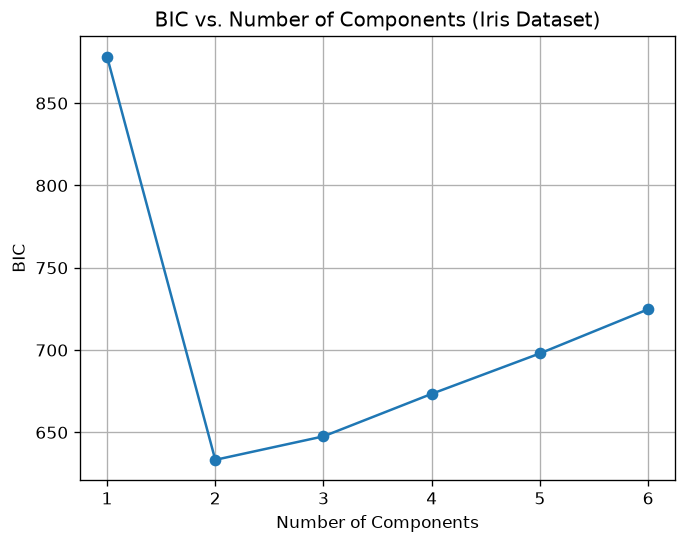

Optimal number of componets by BIC: 2


In [6]:
n_components_range = range(1, 7)
bic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_reduced)
    bic_scores.append(gmm.bic(X_reduced))

plt.figure(dpi=120)
plt.plot(
    n_components_range,
    bic_scores,
    marker='o'
)
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.title('BIC vs. Number of Components (Iris Dataset)')
plt.grid(True)

plt.show()

optimal_n = n_components_range[np.argmin(bic_scores)]
print(f'Optimal number of componets by BIC: {optimal_n}')

### Exercise 4: Effect of covariance type

#### Analyze the impact of different covariance types on the clustering results.
#### 1. Fit GMMs using the full, tied, diag, and spherical covariance types.
#### 2. Plot the clustering results for each type

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\steph\AppData\Local\Temp\ipykernel_7664\4238727431.py:23: UserWarning: You passed an edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\steph\AppData\Local\Temp\ipykernel_7664\4238727431.py:23: UserWarning: You passed an edg

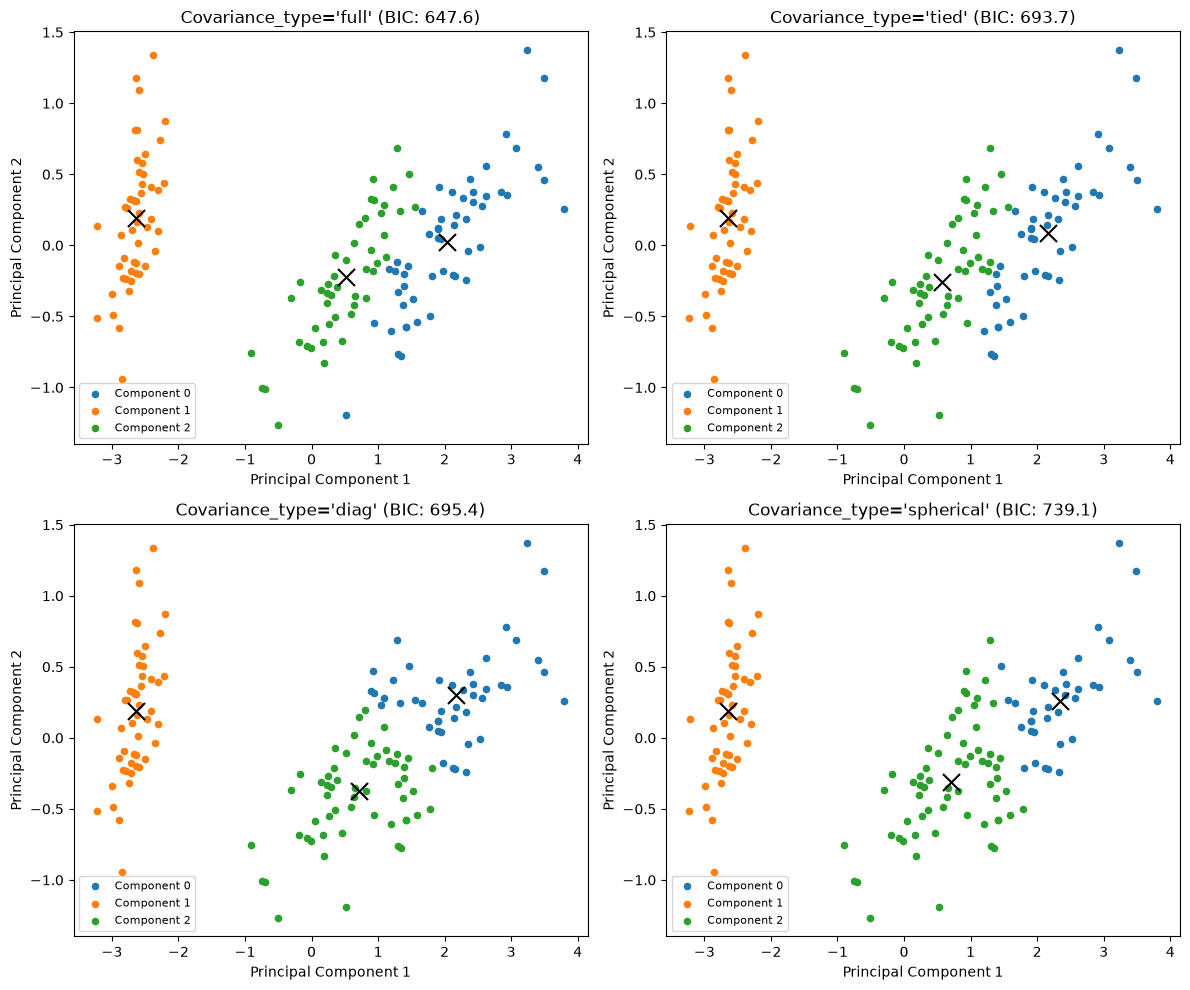

In [8]:
covariance_types = ['full', 'tied', 'diag', 'spherical']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, cov_type in zip(axes, covariance_types):
    gmm = GaussianMixture(
        n_components=3,
        covariance_type=cov_type,
        random_state=42
    )
    labels = gmm.fit_predict(X_reduced)

    for i in range(3):
        subset = X_reduced[labels == i]
        ax.scatter(
            subset[:, 0],
            subset[:, 1],
            label=f'Component {i}',
            s=20
        )

    ax.scatter(
        gmm.means_[:, 0],
        gmm.means_[:, 1],
        c='black',
        marker='x',
        s=150,
        edgecolors='white'
    )

    ax.set_title(f"Covariance_type='{cov_type}' (BIC: {gmm.bic(X_reduced):.1f})")
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()